In [1]:
# %config InlineBackend.figure_format = 'retina'


In [3]:
import warnings
warnings.filterwarnings(action='ignore', category=RuntimeWarning, module='.*messagestream.*')
warnings.filterwarnings('ignore', category=UserWarning, module='keras.engine.training')

# Standard libraries
import os

import pickle
import importlib.machinery
from tqdm import tqdm

# Data handling and numerical operations
import numpy as np
import pandas as pd
from scipy.stats import zscore, stats

# Machine learning
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import RandomForestClassifier
import joblib

from tensorflow.keras.models import save_model, load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import AUC
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# Visualization
import matplotlib.pyplot as plt

# Set logging level for TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

# Import your custom functions
functions = importlib.machinery.SourceFileLoader('module_name', './custom_functions.py').load_module()

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from torch_geometric.data import Data
from torch_geometric.nn import TransformerConv
from torch.optim import Adam
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity



In [4]:
# load TCGA data 
def load_dataframes(exps_filename, key_filename):
    """
    Load gene expression and key DataFrames from files.

    Inputs:
    - exps_filename (str): Path to gene expression file.
    - key_filename (str): Path to gene key file.

    Outputs:
    - gene_exps (DataFrame): Loaded gene expression data.
    - gene_key (DataFrame): Loaded gene key data.
    """
    gene_exps = pd.read_csv(exps_filename, index_col=0)
    gene_key = pd.read_csv(key_filename, index_col=0)
    return gene_exps, gene_key

def normalize_gene_expressions(df):
    """
    Normalize gene expressions using Z-score normalization, preserving the DataFrame structure.

    Inputs:
    - df (DataFrame): DataFrame with gene expression data.

    Outputs:
    - normalized_df (DataFrame): Normalized DataFrame with the same structure as the input.
    """
    # Identify numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Apply z-score normalization only to numeric columns
    df[numeric_cols] = df[numeric_cols].apply(zscore, axis=0)  # Axis=0 ensures column-wise normalization
    
    return df


def load_clinical_manifest(directory):
    """
    Load the clinical manifest from a specified directory.

    Inputs:
    - directory (str): The directory path where the file is located.

    Outputs:
    - clinical_manifest (DataFrame): A DataFrame containing the clinical manifest data.
    """
    filepath = os.path.join(directory, 'clinical_gdc_manifest.txt')
    clinical_manifest = pd.read_csv(filepath, sep='\t')
    print('Clinical manifest shape:', clinical_manifest.shape)
    return clinical_manifest

def clean_dataframe(df):
    """
    Clean a clinical manifest DataFrame by removing irrelevant columns and standardizing health information.

    Inputs:
    - df (DataFrame): Clinical manifest to be cleaned.

    Outputs:
    - df_copy (DataFrame): Cleaned DataFrame.

    Function details:
    - Removes columns that are completely missing or have only uninformative values ('Not Reported', 'None').
    - Updates specific columns with 'healthy tissue' if the sample type indicates a healthy sample.
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_copy = df.copy()

    # Define healthy sample types for classification
    healthy_sample_types = ['Blood Derived Normal', 'Bone Marrow Normal', 'Control Analyte', 'Solid Tissue Normal']

    # List of columns that might indicate health status
    health_info_columns = [
        "ajcc_pathologic_stage", "tumor_grade", "ajcc_pathologic_t", "ajcc_pathologic_m",
        "ajcc_pathologic_n", "figo_stage", "wilms_tumor_histologic_subtype", 'diagnosis_iss_stage',
        'diagnosis_ann_arbor_pathologic_stage', 'diagnosis_ajcc_pathologic_stage'
    ]

    # Remove irrelevant columns and update health information for relevant columns
    for column in df_copy.columns:
        unique_values = df_copy[column].dropna().unique()

        # Drop columns that are completely missing or contain only uninformative values
        if len(unique_values) == 0 or (len(unique_values) == 1 and unique_values[0] in ['Not Reported', 'not reported', 'None']):
            df_copy.drop(column, axis=1, inplace=True)
        else:
            # Update health information for specific columns
            if column in health_info_columns:
                condition = (
                    df_copy['sample_type'].isin(healthy_sample_types) & 
                    df_copy[column].notna() & 
                    df_copy[column].astype(str).str.strip().ne('')
                )
                df_copy.loc[condition, column] = 'healthy tissue'

    # Log the shape of the cleaned DataFrame
    print('Cleaned clinical manifest shape:', df_copy.shape)

    # Return the cleaned DataFrame
    return df_copy

def add_multiple_gene_expressions_to_clinical(gene_exps, clinical_manifest, gene_key, gene_names):
    """
    Add multiple gene expressions to the clinical manifest DataFrame.

    Parameters:
    - gene_exps: DataFrame containing gene expressions.
    - clinical_manifest: DataFrame containing clinical manifest data.
    - gene_key: DataFrame containing gene IDs and names.
    - gene_names: List of gene names to be added.

    Returns:
    - Updated clinical manifest DataFrame with gene expressions.
    """
    for gene_name in gene_names:
        # Find the ENSG code for the given gene_name
        gene_id = gene_key.loc[gene_key['gene_name'] == gene_name, 'gene_id'].iloc[0]
        
        # Extract the relevant gene expression column
        gene_exps_reset = gene_exps.reset_index()
        gene_expression_series = gene_exps_reset.set_index('filename')[gene_id]
        
        # Add the gene expression data to the clinical manifest
        clinical_manifest[gene_name] = clinical_manifest['filename'].apply(lambda x: gene_expression_series.get(x, None))
    
    # Reordering columns to have gene names as the first columns
    cols = gene_names + [col for col in clinical_manifest if col not in gene_names]
    updated_clinical_manifest = clinical_manifest[cols]
    
    return updated_clinical_manifest

def create_cancer_type_column(clinical_manifest):
    """
    Function use:
    Create and add a 'cancer_type' column to the clinical manifest DataFrame based on primary diagnoses.

    Inputs:
    - clinical_manifest (DataFrame): The clinical manifest DataFrame.

    Outputs:
    - new_clinical_manifest (DataFrame): Updated DataFrame with the 'cancer_type' column.

    Function details:
    - Determines cancer type using the 'diagnosis_primary_diagnosis' column.
    - Marks healthy samples as 'Healthy' based on sample types.
    """
    # Create a copy of the clinical manifest to avoid modifying the original DataFrame
    new_clinical_manifest = clinical_manifest.copy()

    # Add 'cancer_type' column using the classify_cancer_type function
    new_clinical_manifest['cancer_type'] = new_clinical_manifest['diagnosis_primary_diagnosis'].apply(classify_cancer_type)

    # Update 'cancer_type' to 'Healthy' for samples with specific healthy sample types
    healthy_sample_types = ['Blood Derived Normal', 'Bone Marrow Normal', 'Control Analyte', 'Solid Tissue Normal']
    new_clinical_manifest.loc[new_clinical_manifest['sample_type'].isin(healthy_sample_types), 'cancer_type'] = 'Healthy'
    
    # Return the updated DataFrame
    return new_clinical_manifest

def create_cancer_type_column(clinical_manifest):
    """
    Function use:
    Create and add a 'cancer_type' column to the clinical manifest DataFrame based on primary diagnoses.

    Inputs:
    - clinical_manifest (DataFrame): The clinical manifest DataFrame.

    Outputs:
    - new_clinical_manifest (DataFrame): Updated DataFrame with the 'cancer_type' column.

    Function details:
    - Determines cancer type using the 'diagnosis_primary_diagnosis' column.
    - Marks healthy samples as 'Healthy' based on sample types.
    """
    # Create a copy of the clinical manifest to avoid modifying the original DataFrame
    new_clinical_manifest = clinical_manifest.copy()

    # Add 'cancer_type' column using the classify_cancer_type function
    new_clinical_manifest['cancer_type'] = new_clinical_manifest['diagnosis_primary_diagnosis'].apply(classify_cancer_type)

    # Update 'cancer_type' to 'Healthy' for samples with specific healthy sample types
    healthy_sample_types = ['Blood Derived Normal', 'Bone Marrow Normal', 'Control Analyte', 'Solid Tissue Normal']
    new_clinical_manifest.loc[new_clinical_manifest['sample_type'].isin(healthy_sample_types), 'cancer_type'] = 'Healthy'
    
    # Return the updated DataFrame
    return new_clinical_manifest

def classify_cancer_type(row):
    """
    Classify cancer types into predefined categories based on primary diagnosis (blood and bone marrow).

    Inputs:
    - row (str): The diagnosis string to classify.

    Outputs:
    - str: The cancer type classification ('Leukemia', 'Lymphoma', 'Myeloma', 'Other_Cancer', or 'Unknown').

    Function details:
    - Matches diagnoses to predefined categories for Leukemia, Lymphoma, Myeloma, and Other_Cancer.
    - Default classification is 'Unknown' if the diagnosis does not match any predefined type.
    """
    leukemia_types = [
        "Acute myeloid leukemia, NOS", "Common precursor B ALL", "Acute lymphocytic leukemia",
        "Acute myeloid leukemia with mutated NPM1", "Acute lymphoblastic leukemia, NOS",
        "Acute myeloid leukemia with myelodysplasia-related changes", "Leukemia, NOS",
        "Acute myeloid leukemia, CBF-beta/MYH11", "Acute myeloid leukemia with mutated CEBPA",
        "Acute myelomonocytic leukemia", "Acute promyelocytic leukaemia, PML-RAR-alpha",
        "Atypical chronic myeloid leukemia, BCR/ABL negative", "Acute monoblastic and monocytic leukemia",
        "Chronic neutrophilic leukemia", "Acute myeloid leukemia with t(8;21)(q22;q22); RUNX1-RUNX1T1",
        "Acute myeloid leukemia with t(9;11)(p22;q23); MLLT3-MLL",
        "Acute myeloid leukemia with inv(3)(q21q26.2) or t(3;3)(q21;q26.2); RPN1-EVI1",
        "Acute leukemia, NOS", "Acute myeloid leukemia, minimal differentiation",
        "Precursor B-cell lymphoblastic leukemia", "Precursor cell lymphoblastic leukemia, not phenotyped",
        "Precursor cell lymphoblastic leukemia, NOS", "Chronic myelomonocytic leukemia, NOS",
        "Acute myeloid leukemia with t(6;9)(p23;q34); DEK-NUP214", "Mixed phenotype acute leukemia, T/myeloid, NOS",
        "Acute erythroid leukaemia", "Refractory anemia with excess blasts", "Subacute lymphoid leukemia",
        "Essential thrombocythemia", "Mixed phenotype acute leukemia, B/myeloid, NOS",
        "Acute megakaryoblastic leukaemia", "Undifferentiated leukaemia", "Lymphoid leukemia, NOS",
        "Myeloid leukemia associated with Down Syndrome", "Chronic lymphocytic leukemia"
    ]
    
    lymphoma_types = [
        "Burkitt lymphoma, NOS (Includes all variants)", "Diffuse large B-cell lymphoma, NOS",
        "Burkitt-like lymphoma", "B cell lymphoma, NOS", "EBV positive diffuse large B-cell lymphoma of the elderly",
        "Primary diffuse large B-cell lymphoma of the CNS",
        "B-cell lymphoma, unclassifiable, with features intermediate between diffuse large B-cell lymphoma and Burkitt lymphoma"
    ]
    
    myeloma_types = [
        "Multiple myeloma", "Plasma cell myeloma"
    ]
    
    other_types = [
        "Therapy related myeloid neoplasm", "Myelodysplastic/myeloproliferative neoplasm, unclassifiable",
        "Myloproliferative neoplasm, unclassifiable", "Myeloid sarcoma", "Myelodysplastic syndrome, unclassifiable",
        "Refractory cytopenia with multilineage dysplasia", "Neuroblastoma, NOS", "Osteosarcoma, NOS",
        "Neoplasm, uncertain whether benign or malignant", "Blastic plasmacytoid dendritic cell neoplasm",
        "Tumor, NOS"
    ]
    
    unknown_types = [
        "Not Reported", "Unknown"
    ]
    
    # Match the diagnosis to predefined categories
    if row in leukemia_types:
        return 'Leukemia'
    elif row in lymphoma_types:
        return 'Lymphoma'
    elif row in myeloma_types:
        return 'Myeloma'
    elif row in other_types:
        return 'Other_Cancer'
    elif row in unknown_types:
        return 'Unknown'
    else:
        # Default to 'Other' for unmatched diagnoses
        return 'Other'

def combine_stages(stage):
    """
    Combine detailed cancer stages into broader categories for standardization.

    Inputs:
    - stage (str): Detailed stage string.

    Outputs:
    - str: Combined stage string or 'Unknown' for missing/unknown data.

    Function details:
    - Maps detailed cancer stages (e.g., 'Stage IA') to broader categories (e.g., 'Stage I').
    - Returns 'Unknown' for missing or uninformative stage data.
    """
    # Define mapping from detailed to broader stages
    stage_mapping = {
        'Stage IA': 'Stage I', 'Stage IA1': 'Stage I', 'Stage IA2': 'Stage I', 'Stage IA3': 'Stage I', 'Stage IB': 'Stage I', 'Stage IC': 'Stage I',
        'Stage IIA': 'Stage II', 'Stage IIB': 'Stage II', 'Stage IIC': 'Stage II', 'Stage IIIC1': 'Stage II', 'Stage IIIC2': 'Stage II',
        'Stage IIIA': 'Stage III', 'Stage IIIB': 'Stage III', 'Stage IIIC': 'Stage III',
        'Stage IVA': 'Stage IV', 'Stage IVB': 'Stage IV', 'Stage IVC': 'Stage IV',
        'Stage X': 'Stage X'
    }
    
    # Handle missing or unknown stage values
    if pd.isna(stage) or stage in ["Unknown", "Not Reported"]:
        return "Unknown"
    
    # Return the mapped broader stage or the original stage if not in the mapping
    return stage_mapping.get(stage, stage)

def add_multiple_gene_expressions_to_clinical(gene_exps, clinical_manifest, gene_key, gene_names):
    """
    Add multiple gene expressions to the clinical manifest DataFrame.

    Parameters:
    - gene_exps: DataFrame containing gene expressions.
    - clinical_manifest: DataFrame containing clinical manifest data.
    - gene_key: DataFrame containing gene IDs and names.
    - gene_names: List of gene names to be added.

    Returns:
    - Updated clinical manifest DataFrame with gene expressions.
    """
    for gene_name in gene_names:
        # Find the ENSG code for the given gene_name
        gene_id = gene_key.loc[gene_key['gene_name'] == gene_name, 'gene_id'].iloc[0]
        
        # Extract the relevant gene expression column
        gene_exps_reset = gene_exps.reset_index()
        gene_expression_series = gene_exps_reset.set_index('filename')[gene_id]
        
        # Add the gene expression data to the clinical manifest
        clinical_manifest[gene_name] = clinical_manifest['filename'].apply(lambda x: gene_expression_series.get(x, None))
    
    # Reordering columns to have gene names as the first columns
    cols = gene_names + [col for col in clinical_manifest if col not in gene_names]
    updated_clinical_manifest = clinical_manifest[cols]
    
    return updated_clinical_manifest

def add_multiple_gene_expressions_to_clinical(gene_exps, clinical_manifest, gene_key, gene_names):
    """
    Add multiple gene expressions to the clinical manifest DataFrame.

    Parameters:
    - gene_exps: DataFrame containing gene expressions.
    - clinical_manifest: DataFrame containing clinical manifest data.
    - gene_key: DataFrame containing gene IDs and names.
    - gene_names: List of gene names to be added.

    Returns:
    - Updated clinical manifest DataFrame with gene expressions.
    """
    # Remove version numbers from gene IDs
    gene_key['gene_id'] = gene_key['gene_id'].str.split('.').str[0]
    gene_exps_reset = gene_exps.reset_index()
    gene_exps_reset.columns = gene_exps_reset.columns.str.split('.').str[0]

    for gene_name in gene_names:
        try:
            # Find the ENSG code for the given gene_name
            gene_id = gene_key.loc[gene_key['gene_name'] == gene_name, 'gene_id'].iloc[0]
        except IndexError:
            print(f"Gene name '{gene_name}' not found in gene_key.")
            continue

        if gene_id not in gene_exps_reset.columns:
            print(f"Gene ID '{gene_id}' for gene '{gene_name}' not found in gene_exps.")
            continue

        # Extract the relevant gene expression column
        gene_expression_series = gene_exps_reset.set_index('filename')[gene_id]

        # Add the gene expression data to the clinical manifest
        clinical_manifest[gene_name] = clinical_manifest['filename'].apply(lambda x: gene_expression_series.get(x, None))

    # Reordering columns to have gene names as the first columns
    cols = gene_names + [col for col in clinical_manifest if col not in gene_names]
    updated_clinical_manifest = clinical_manifest[cols]

    return updated_clinical_manifest
def process_gene_expression_data(clinical_manifest, gene_exps, gene_key):
    """
    Process clinical manifest and gene expression data to produce a final DataFrame.

    Args:
    - clinical_manifest (DataFrame): Clinical manifest containing metadata and cancer stage.
    - gene_exps (DataFrame): Gene expression data with ENSG IDs as columns and filenames as index.
    - gene_key (DataFrame): Mapping of ENSG IDs to gene names.

    Returns:
    - DataFrame: A DataFrame with filename as row names, gene names as columns (or gene names with ENSG ID if duplicates), and an output column.
    """
    # Step 1: Ensure filename column is present in gene_exps
    gene_exps = gene_exps.reset_index()

    # Step 2: Merge clinical manifest with gene expression data
    merged_df = clinical_manifest[['filename', 'cancer_stage']].merge(gene_exps, on='filename', how='inner')

    # Step 3: Map ENSG IDs to gene names
    ensg_to_gene = dict(zip(gene_key['gene_id'], gene_key['gene_name']))
    gene_columns = [col for col in merged_df.columns if col.startswith('ENSG')]

    # Create a DataFrame to handle renaming efficiently
    renaming_df = pd.DataFrame({'ensg_id': gene_columns})
    renaming_df['gene_name'] = renaming_df['ensg_id'].map(ensg_to_gene)
    renaming_df['gene_name'] = renaming_df.apply(
        lambda row: ensg_to_gene.get(row['ensg_id'].split('.')[0], row['ensg_id']) 
        if pd.isna(row['gene_name']) else row['gene_name'], axis=1
    )

    # Add ENSG ID to duplicated gene names
    gene_name_counts = renaming_df['gene_name'].value_counts()
    renaming_df['final_name'] = renaming_df.apply(
        lambda row: f"{row['gene_name']}({row['ensg_id']})" if gene_name_counts[row['gene_name']] > 1 else row['gene_name'], axis=1
    )

    renamed_columns = dict(zip(renaming_df['ensg_id'], renaming_df['final_name']))
    merged_df.rename(columns=renamed_columns, inplace=True)

    # Step 4: Shift gene expression values to make them positive
    gene_data = merged_df[list(renamed_columns.values())]
    min_values = gene_data.min()
    gene_data += (abs(min_values) + 1e-6)  # Small constant to avoid zero values
    merged_df.update(gene_data)

    # Step 4: Reorder columns with `output` first, followed by gene names
    merged_df['output'] = merged_df['cancer_stage'].map(
        lambda x: -1 if x.lower() in ['healthy', 'healthy tissue'] else
                  0 if x in ['Stage I', 'Stage II'] else
                  1 if 'Stage' in str(x) else -99
    )
    # Step 4: Reorder columns with `output` first, followed by gene names
    merged_df['output'] = merged_df['cancer_stage'].map(
        lambda x: 0 if x.lower() in ['healthy', 'healthy tissue'] else
                  1 if x in ['Stage I', 'Stage II'] else
                  1 if 'Stage' in str(x) else -99
    )
    
    # Step 6: Reorder columns with output first, followed by genes
    final_columns = ['output'] + list(renamed_columns.values())
    final_df = merged_df[['filename'] + final_columns]
    final_df.set_index('filename', inplace=True)

    return final_df

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
from sklearn import manifold
import umap
from matplotlib.colors import Normalize

def visualize_training_data_with_umap_and_tsne(X_train, y_train):
    """
    Perform initial visualization of the training data using UMAP and t-SNE.

    Parameters
    ----------
    X_train : numpy array
        The training features.

    y_train : pandas Series or numpy array
        The training labels.
    """

    # Encode labels as integers
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(y_train)

    # Generate colormap and normalization for discrete labels
    num_labels = len(np.unique(encoded_labels))
    colormap = plt.cm.bwr
    norm = Normalize(vmin=0, vmax=num_labels - 1)

    # Create a figure with subplots for UMAP and t-SNE visualizations
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle('Visualization of training data using UMAP and t-SNE')

    # UMAP plot
    umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
    umap_out = umap_model.fit_transform(X_train)
    axs[0].scatter(umap_out[:, 0], umap_out[:, 1], c=encoded_labels, cmap=colormap, norm=norm, alpha=0.5)
    axs[0].set_title('UMAP')
    axs[0].set_xlabel('UMAP Component 1')
    axs[0].set_ylabel('UMAP Component 2')

    # t-SNE plot
    tsne = manifold.TSNE(n_components=2, learning_rate='auto', init='random', perplexity=30, random_state=0)
    tsne_out = tsne.fit_transform(X_train)
    axs[1].scatter(tsne_out[:, 0], tsne_out[:, 1], c=encoded_labels, cmap=colormap, norm=norm, alpha=0.5)
    axs[1].set_title('t-SNE')
    axs[1].set_xlabel('t-SNE Component 1')
    axs[1].set_ylabel('t-SNE Component 2')

    # Adjust spacing between subplots
    plt.tight_layout()

    # Show the plot
    plt.show()

import os
import pickle

def save_pickle_data(save_dir, **kwargs):
    """
    Save multiple objects as pickle files in the specified directory.

    Parameters:
    - save_dir: str, the directory to save the pickle files.
    - kwargs: key-value pairs of object names and objects to save.
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    for name, data in kwargs.items():
        file_path = os.path.join(save_dir, f"{name}.pkl")
        with open(file_path, "wb") as f:
            pickle.dump(data, f)
        print(f"Saved {name} to {file_path}")

def load_pickle_data(load_dir, *args):
    """
    Load multiple objects from pickle files in the specified directory.

    Parameters:
    - load_dir: str, the directory to load the pickle files from.
    - args: list of object names to load.

    Returns:
    - A dictionary of loaded objects.
    """
    loaded_data = {}

    for name in args:
        file_path = os.path.join(load_dir, f"{name}.pkl")
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"{file_path} does not exist.")

        with open(file_path, "rb") as f:
            loaded_data[name] = pickle.load(f)
        print(f"Loaded {name} from {file_path}")

    return loaded_data

def model_evaluation(model, X_train, y_train, folds=5):
    """
    Perform k-fold cross-validation and plot stacked AUROC and AUPRC curves.

    Parameters
    ----------
    model : object
        The model to be evaluated.

    X_train : numpy array
        The training features.

    y_train : numpy array
        The training labels.

    folds : int, default=5
        The number of cross-validation folds.
    """
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_curve, precision_recall_curve, auc, f1_score, accuracy_score
    import numpy as np
    import matplotlib.pyplot as plt

    cv = StratifiedKFold(n_splits=folds)

    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    precision_array = []
    recall_array = []
    pr_aucs = []
    mean_recall = np.linspace(0, 1, 100)

    f1_scores = []
    accuracy_scores = []

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    for i, (train, test) in enumerate(cv.split(X_train, y_train)):
        model.fit(X_train[train], y_train[train])
        y_pred = model.predict(X_train[test])
        y_score = model.predict_proba(X_train[test])[:, 1]

        # Compute ROC curve and ROC area
        fpr, tpr, _ = roc_curve(y_train[test], y_score)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)  # Align TPR to mean FPR
        interp_tpr[0] = 0.0  # Set the first value to 0
        tprs.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        ax1.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {i} (AUC = {roc_auc:.2f})')

        # Compute precision-recall curve and PR area
        precision, recall, _ = precision_recall_curve(y_train[test], y_score)
        interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])  # Align precision
        precision_array.append(interp_precision)
        pr_auc = auc(recall, precision)
        pr_aucs.append(pr_auc)

        ax2.plot(recall, precision, lw=1, alpha=0.3, label=f'PR fold {i} (AUC = {pr_auc:.2f})')

        # Compute F1 score and accuracy
        f1_scores.append(f1_score(y_train[test], y_pred))
        accuracy_scores.append(accuracy_score(y_train[test], y_pred))

    # Plot mean ROC curve
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    ax1.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=.8)
    ax1.plot([0, 1], [0, 1], color='grey', linestyle='--')
    ax1.set_title('ROC Curve')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.legend(loc="lower right")

    # Plot mean PR curve
    mean_precision = np.mean(precision_array, axis=0)
    mean_pr_auc = auc(mean_recall, mean_precision)
    ax2.plot(mean_recall, mean_precision, color='b', label=f'Mean PR (AUC = {mean_pr_auc:.2f})', lw=2, alpha=.8)
    ax2.plot([0, 1], [np.mean(y_train), np.mean(y_train)], color='grey', linestyle='--')
    ax2.set_title('Precision-Recall Curve')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    print(f"Average F1 score: {np.mean(f1_scores):.2f}")
    print(f"Average Accuracy: {np.mean(accuracy_scores):.2f}")
    print(f"Average AUROC: {np.mean(aucs):.2f}")
    print(f"Average AUPRC: {np.mean(pr_aucs):.2f}")



In [6]:
cancer = "thyroid"
gene_names = ["OGA", "OGT"]

clinical_manifest = load_clinical_manifest(f'./data/TCGA_GeneExpression/{cancer}/')
clinical_manifest = clean_dataframe(clinical_manifest)

gene_exps, gene_key = load_dataframes(f'./data/TCGA_GeneExpression/{cancer}/gene_expression.csv', 
                                              f'./data/TCGA_GeneExpression/{cancer}/gene_key.csv')
gene_exps = normalize_gene_expressions(gene_exps)

clinical_manifest_duo = add_multiple_gene_expressions_to_clinical(gene_exps, clinical_manifest, gene_key, gene_names)
clinical_manifest_duo = create_cancer_type_column(clinical_manifest_duo)
clinical_manifest_duo['cancer_stage'] = clinical_manifest_duo['diagnosis_ajcc_pathologic_stage'].apply(combine_stages)

Clinical manifest shape: (1402, 177)
Cleaned clinical manifest shape: (1402, 55)


In [7]:
clinical_manifest_duo

,OGA,OGT,id,filename,md5,size,state,tissue_or_organ_of_origin,age_at_diagnosis,primary_diagnosis,...,diagnosis_icd_10_code,diagnosis_synchronous_malignancy,diagnosis_days_to_diagnosis,diagnosis_days_to_last_follow_up,diagnosis_prior_malignancy,diagnosis_year_of_diagnosis,diagnosis_ann_arbor_extranodal_involvement,diagnosis_ajcc_staging_system_edition,cancer_type,cancer_stage
0,0.200777,-0.406137,9d3e5c10-4b69-418b-905b-8a9d59f1b046,8766ef80-ad3c-4bc0-90fc-c9490a8c136d.rna_seq.a...,98744c5f233585065a2892831c2322e9,4257447,released,Thyroid gland,NaN,"Papillary adenocarcinoma, NOS",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Healthy,Unknown
1,2.130385,2.147400,6bee7d35-0242-4d9a-b342-56f541f9c77c,6da89125-013a-4cb1-9a0f-220c3a1d35d0.rna_seq.a...,547c771ff5baa5183a6d4facd21b5812,4278547,released,Thyroid gland,NaN,"Papillary adenocarcinoma, NOS",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Healthy,Unknown
2,0.455400,-0.556605,1b384a86-e285-486d-abe2-e6e50cb5f8d2,d92f9352-85b7-4172-b063-a8145bcfbf42.rna_seq.a...,7c5713d1b9673f0cc21adf65c497971d,4228464,released,Thyroid gland,NaN,"Papillary adenocarcinoma, NOS",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,Unknown
3,0.984501,0.955038,5f16ea8f-3d2a-4857-a91c-290259811d6a,9ae05346-a9f7-4326-99d2-d9b4b802e0bd.rna_seq.a...,91a6e5b6fc2c0dce2985b4cdcc03be02,4250288,released,Thyroid gland,NaN,"Papillary adenocarcinoma, NOS",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Healthy,Unknown
4,0.441001,0.728629,5c2db08c-9235-4b66-aa23-d131792fa996,05122b8d-865c-4ed4-af10-bbdfa12e12d7.rna_seq.a...,2fdae246c29333ec68d82c01d2d4bdac,4248552,released,Thyroid gland,NaN,"Papillary adenocarcinoma, NOS",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1397,-1.038275,-0.710687,874e967d-c443-4bad-9364-806aad232bba,27d57c31-b3fd-445c-a04b-324ec1999bb6.rna_seq.a...,886b335529c301d08be16c2f3878718b,4233270,released,Thyroid gland,6684.0,"Papillary adenocarcinoma, NOS",...,C73,No,0.0,356.0,no,2011.0,NaN,7th,Other,Stage I
1398,-1.045595,-0.685922,0d3609fb-8e1a-4bda-bc95-0b59006f24ac,16b193ec-6a1a-420b-9dbf-f49ca38e835f.rna_seq.a...,daf5f294793971744ce6135fb5dce343,4245631,released,Thyroid gland,28147.0,"Papillary adenocarcinoma, NOS",...,C73,No,0.0,577.0,no,2011.0,NaN,7th,Other,Stage III
1399,-0.961516,-1.290104,f727d2a5-0c7a-45ad-a9ca-42abc2bc4e61,2b7a660d-f472-476a-9145-cae4f3ba5e4c.rna_seq.a...,4f3cb5602954f04a88179e1938cd9151,4250890,released,Thyroid gland,17734.0,"Papillary adenocarcinoma, NOS",...,C73,No,0.0,885.0,no,2011.0,NaN,7th,Other,Stage III
1400,-0.410162,0.020005,be9a94c5-3d86-44b8-8de2-043c0ac2b033,a5ee5405-4573-4933-85b6-0f9e6a2c6fda.rna_seq.a...,6db8ad08e514667eb3ea614f238a8970,4215071,released,Thyroid gland,7176.0,"Papillary adenocarcinoma, NOS",...,C73,No,0.0,492.0,no,2011.0,NaN,7th,Other,Stage I


In [8]:


clean_data = process_gene_expression_data(clinical_manifest_duo, gene_exps, gene_key)
print(clean_data['output'].value_counts())
clean_data = clean_data[(clean_data['output'].isin([0, 1]))]
print(clean_data['output'].value_counts())
clean_data.columns = pd.MultiIndex.from_tuples([(col,) for col in clean_data.columns])
clean_data = clean_data.dropna(axis=1)
clean_data

output
-99    809
 1     523
 0      70
Name: count, dtype: int64
output
1    523
0     70
Name: count, dtype: int64


,output,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC010980.1,AC007511.1,AC004233.4,AC092910.4,AC073611.1,AC078856.1,AC008763.4,AL592295.6,AL391628.1,AP006621.6
filename,,,,,,,,,,,,,,,,,,,,,
8b08d8d5-1a6e-483b-8345-246ab47ac267.rna_seq.augmented_star_gene_counts.tsv,0,2.945427,0.768339,4.781930,2.630002,2.010509,0.132881,1.574673,1.873962,1.465884,...,1.658412,0.000001,0.483990,1.529400,2.556993,1.854261,0.000001,3.426198,1.128247,0.715658
06841058-69f5-4639-94a3-b6e6e4914927.rna_seq.augmented_star_gene_counts.tsv,1,3.135012,0.888349,4.034540,2.658343,2.292394,1.283409,2.820923,1.733046,1.540584,...,0.364232,0.000001,2.247058,1.144237,1.278497,1.192056,0.000001,2.918752,1.816476,0.860139
dbee7256-1797-4a9d-9433-49599f92f5bd.rna_seq.augmented_star_gene_counts.tsv,0,3.032546,0.991805,3.996904,3.495708,1.816487,0.247406,0.657483,1.884571,1.884461,...,2.630778,0.000001,0.431070,0.653583,1.476853,1.134806,0.000001,3.478233,1.241071,0.852713
174d8f76-21ab-445d-93ee-e8ebbc61c134.rna_seq.augmented_star_gene_counts.tsv,0,2.991223,1.776696,3.966767,3.336087,2.456325,0.377313,1.112132,1.926761,1.643508,...,1.769435,0.000001,0.276548,1.377446,2.935673,1.868474,0.000001,3.524839,1.444155,0.898623
5dfbc8a2-345d-437d-b6cf-b81d26ced58d.rna_seq.augmented_star_gene_counts.tsv,0,3.322745,0.864898,4.387311,3.466140,2.669845,0.721920,1.348581,1.993420,1.435538,...,1.401091,0.000001,1.083582,1.292240,2.196345,1.083174,0.000001,3.718454,1.895454,0.650843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27d57c31-b3fd-445c-a04b-324ec1999bb6.rna_seq.augmented_star_gene_counts.tsv,1,3.327580,0.000001,3.948616,1.567131,2.187680,2.347795,2.124224,4.193274,0.603174,...,0.083106,0.000001,0.040333,0.000001,1.370462,0.000001,0.000001,1.602790,0.801055,1.740532
16b193ec-6a1a-420b-9dbf-f49ca38e835f.rna_seq.augmented_star_gene_counts.tsv,1,3.444308,0.549011,3.522655,1.969802,1.743789,2.444561,1.298080,3.097644,1.262887,...,0.021426,0.000001,0.077840,0.000001,0.697854,0.000001,0.000001,2.843097,0.688231,1.475874
2b7a660d-f472-476a-9145-cae4f3ba5e4c.rna_seq.augmented_star_gene_counts.tsv,1,2.658980,0.103458,2.867630,3.042733,1.004533,0.224097,0.134059,2.189781,1.410375,...,3.449704,0.000001,0.039177,0.000001,1.366856,0.018517,0.967213,4.107447,1.173376,0.444923


x_train shape: (474, 58189)    y_train shape: (474,)
x_test shape : (119, 58189)    y_test shape: (119,)


/Users/rstojsin/miniconda3/envs/tf_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/rstojsin/miniconda3/envs/tf_env/lib/python3.11/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


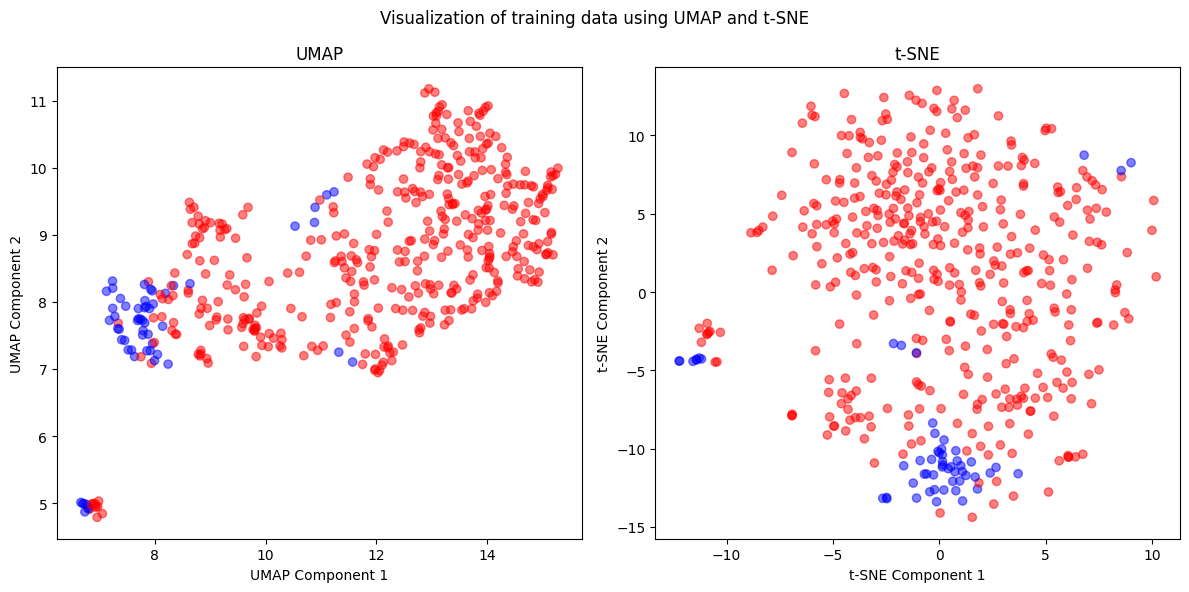

In [9]:
x_train, x_test, y_train, y_test = functions.train_test_splitting(clean_data)
visualize_training_data_with_umap_and_tsne(x_train, y_train)

--- {'KernelPCA'}  ---


/Users/rstojsin/miniconda3/envs/tf_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


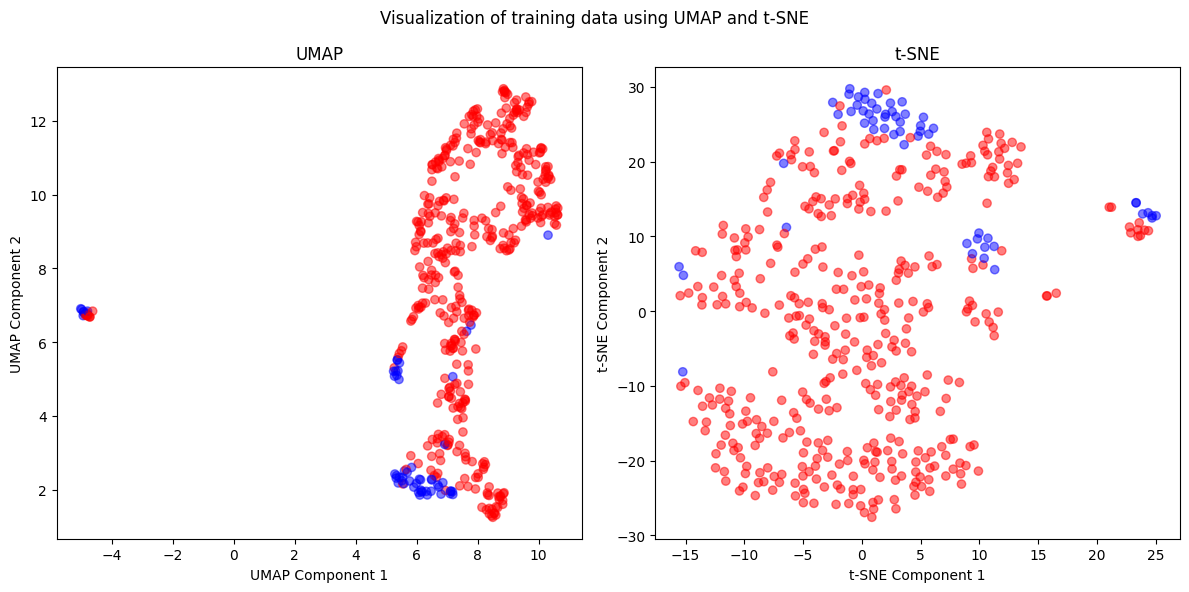

In [10]:
k = 10
# 'PCA', 'FA', 'LDA', 'SVD', 'KernelPCA', 'SparsePCA', 'Isomap', 'ICA', 'NMF'
reducer =  'KernelPCA'
print("---", {reducer}, " ---")
x_train_reduced, x_test_reduced, kernelpca_reducer = functions.apply_dimensionality_reduction(x_train, x_test, reducer, k)
visualize_training_data_with_umap_and_tsne(x_train_reduced, y_train)

In [ ]:

# # Example usage:
# temp_dir = "/tmp/gene_network_data"

# # Save data
# save_pickle_data(temp_dir, 
#                  x_train_reduced=x_train_reduced, 
#                  x_test_reduced=x_test_reduced, 
#                  kernelpca_reduced=kernelpca_reducer, 
#                  y_train=y_train)


In [11]:
# Example usage:
temp_dir = "/tmp/gene_network_data"
# Load data
loaded_data = load_pickle_data(temp_dir, "x_train_reduced", "x_test_reduced", "kernelpca_reduced", "y_train")
x_train_reduced = loaded_data["x_train_reduced"]
x_test_reduced = loaded_data["x_test_reduced"]
kernelpca_reducer = loaded_data["kernelpca_reduced"]
y_train = loaded_data["y_train"]

FileNotFoundError: /tmp/gene_network_data/x_train_reduced.pkl does not exist.

In [ ]:
x_train

In [ ]:
x_train_reduced.shape

In [ ]:
y_train

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from scipy.interpolate import interp1d

def model_evaluation_log(model, X_train, y_train, folds=5):
    """
    Perform k-fold cross-validation and plot stacked AUROC and AUPRC curves.

    Parameters
    ----------
    model : object
        The model to be evaluated.

    X_train : numpy array
        The training features.

    y_train : numpy array or pandas Series
        The training labels.

    folds : int, default=5
        The number of cross-validation folds.
    """

    # Ensure y_train is a NumPy array (to avoid index mismatch issues)
    if isinstance(y_train, pd.Series):
        y_train = y_train.to_numpy()

    cv = StratifiedKFold(n_splits=folds)

    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    precision_array = []
    recall_array = []
    pr_aucs = []
    mean_recall = np.linspace(0, 1, 100)

    f1_scores = []
    accuracy_scores = []

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    for i, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
        # print(f"[DEBUG] Fold {i+1}: Train size={len(train_idx)}, Test size={len(test_idx)}")

        model.fit(X_train[train_idx], y_train[train_idx])
        y_pred = model.predict(X_train[test_idx])
        y_score = model.predict_proba(X_train[test_idx])[:, 1]

        # Compute ROC curve and ROC area
        fpr, tpr, thresholds = roc_curve(y_train[test_idx], y_score)
        interp_tpr = interp1d(fpr, tpr, bounds_error=False, fill_value=(0, 1))(mean_fpr)  # Fixed interpolation
        tprs.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        ax1.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {i+1} (AUC = {roc_auc:.2f})')

        # Compute precision-recall curve and PR area
        precision, recall, _ = precision_recall_curve(y_train[test_idx], y_score)
        interp_precision = interp1d(recall[::-1], precision[::-1], bounds_error=False, fill_value=(1, 0))(mean_recall)
        precision_array.append(interp_precision)
        pr_auc = auc(recall, precision)
        pr_aucs.append(pr_auc)

        ax2.plot(recall, precision, lw=1, alpha=0.3, label=f'PR fold {i+1} (AUC = {pr_auc:.2f})')

        # Compute F1 score and accuracy
        f1_scores.append(f1_score(y_train[test_idx], y_pred))
        accuracy_scores.append(accuracy_score(y_train[test_idx], y_pred))

    # Plot mean ROC curve
    ax1.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Baseline (0.50)")
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)
    ax1.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=.8)

    ax1.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], title="Receiver Operating Characteristic (ROC)")
    ax1.legend(loc="lower right")

    # Plot mean PR curve (✅ FIXED BASELINE PLOTTING ERROR)
    ax2.plot([0, 1], [np.mean(y_train)] * 2, color="grey", linestyle="--", label=f"Baseline ({np.mean(y_train):.4f})")
    mean_precision = np.mean(precision_array, axis=0)
    mean_pr_auc = auc(mean_recall, mean_precision)
    ax2.plot(mean_recall, mean_precision, color='b', label=f'Mean PR (AUC = {mean_pr_auc:.2f})', lw=2, alpha=.8)

    ax2.set(xlim=[-0.05, 1.05],  ylim=[np.mean(y_train)-0.05, 1.0], title="Precision-Recall Curve")
    ax2.legend(loc="lower right")

    plt.show()

    # Print averaged performance metrics
    print(f"Average F1 Score: {np.mean(f1_scores):.2f}")
    print(f"Average Accuracy: {np.mean(accuracy_scores):.2f}")
    print(f"Average AUROC: {np.mean(aucs):.2f}")
    print(f"Average AUPRC: {np.mean(pr_aucs):.2f}")



2025-02-25 10:57:55.914536: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-25 10:57:55.935529: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp_2.


3/3 [==============================] - 0s 2ms/step


2025-02-25 10:58:02.000132: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-25 10:58:02.247562: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-25 10:58:02.267501: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp_2.


3/3 [==============================] - 0s 2ms/step


2025-02-25 10:58:08.983980: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-25 10:58:09.218161: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-25 10:58:09.239315: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp_2.


...

2025-02-25 10:58:16.175879: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-25 10:58:16.410430: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-25 10:58:16.431399: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp_2.


3/3 [==============================] - 0s 2ms/step


2025-02-25 10:58:23.728476: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-25 10:58:23.962237: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-25 10:58:23.983105: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp_2.


3/3 [==============================] - 0s 2ms/step


2025-02-25 10:58:30.970954: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


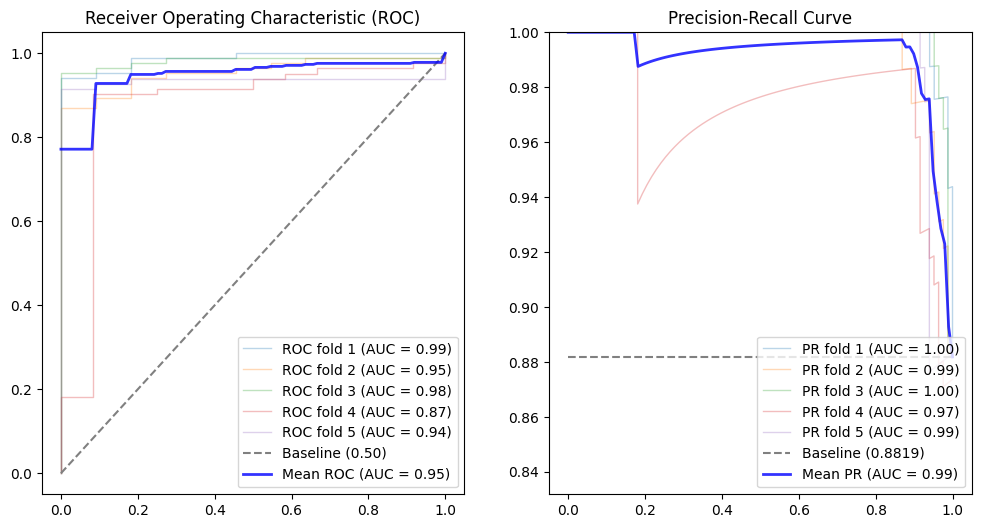

Average F1 Score: 0.92
Average Accuracy: 0.87
Average AUROC: 0.95
Average AUPRC: 0.99


2025-02-25 10:58:31.330027: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-25 10:58:31.350398: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp_2.


15/15 [==============================] - 0s 2ms/step


2025-02-25 10:58:39.073486: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


In [43]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)  # Suppress deprecation warnings

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import AUC
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve

# Creating LOG Model
def create_logistic_model(input_dim):
    model = Sequential()
    model.add(Dense(1, activation='sigmoid', input_dim=input_dim))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[AUC(name='auc')])
    return model

input_dim = x_train_reduced.shape[1]


# **Fix y_train format: Convert to NumPy array**
y_train_fixed = y_train.to_numpy()  # Convert to NumPy array, removing index issues
# Wrapping the Keras model with KerasClassifier
log_model = KerasClassifier(build_fn=lambda: create_logistic_model(input_dim), epochs=100, batch_size=32, verbose=0)

# Using the custom evaluation function with fixed y_train
folds = 5
model_evaluation_log(log_model, x_train_reduced, y_train_fixed, folds)

# Fit LOG model on training data
log_model.fit(x_train_reduced, y_train_fixed)

# Save the trained model as an H5 file
log_model.model.save('./results/models_new/log_thyroid_10_KernelPCA.h5')

# Ensure y_score and y_train have the same length for ROC computation
y_score = log_model.predict_proba(x_train_reduced)[:, 1]

# Debug: Check if there is a mismatch between y_train and y_score
if len(y_train_fixed) != len(y_score):
    raise ValueError("y_train and y_score must have the same length.")

# Compute ROC curve safely
try:
    fpr, tpr, thresholds = roc_curve(y_train_fixed, y_score)
except ValueError as e:
    print(f"[ERROR] Error computing ROC curve: {e}")




In [ ]:
model.model.save('./results/models_new/log_thyroid_10_KernelPCA.h5')
del model

print('------------------------------ LOG MODEL ------------------------------')
functions.print_model_summary('./results/models_new/log_thyroid_10_KernelPCA.h5')

/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1828228230.py:26: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasClassifier(build_fn=lambda: create_mlp_model(input_dim), epochs=100, batch_size=32, verbose=0)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:565: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model.fit(X_train[train], y_train[train])
2025-02-24 13:23:43.684622: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-02-24 13:23:43.

3/3 [==============================] - 0s 2ms/step


2025-02-24 13:23:54.126963: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:570: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, _ = roc_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:580: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precision, recall, _ = precision_recall_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:589: FutureW

3/3 [==============================] - 0s 2ms/step


2025-02-24 13:24:03.672177: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:570: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, _ = roc_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:580: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precision, recall, _ = precision_recall_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:589: FutureW

...

2025-02-24 13:24:14.439959: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:570: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, _ = roc_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:580: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precision, recall, _ = precision_recall_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:589: FutureW

3/3 [==============================] - 0s 2ms/step


2025-02-24 13:24:25.193101: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:570: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, _ = roc_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:580: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precision, recall, _ = precision_recall_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:589: FutureW

3/3 [==============================] - 0s 3ms/step


2025-02-24 13:24:35.597670: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:570: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, _ = roc_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:580: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precision, recall, _ = precision_recall_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_67374/1821789406.py:589: FutureW

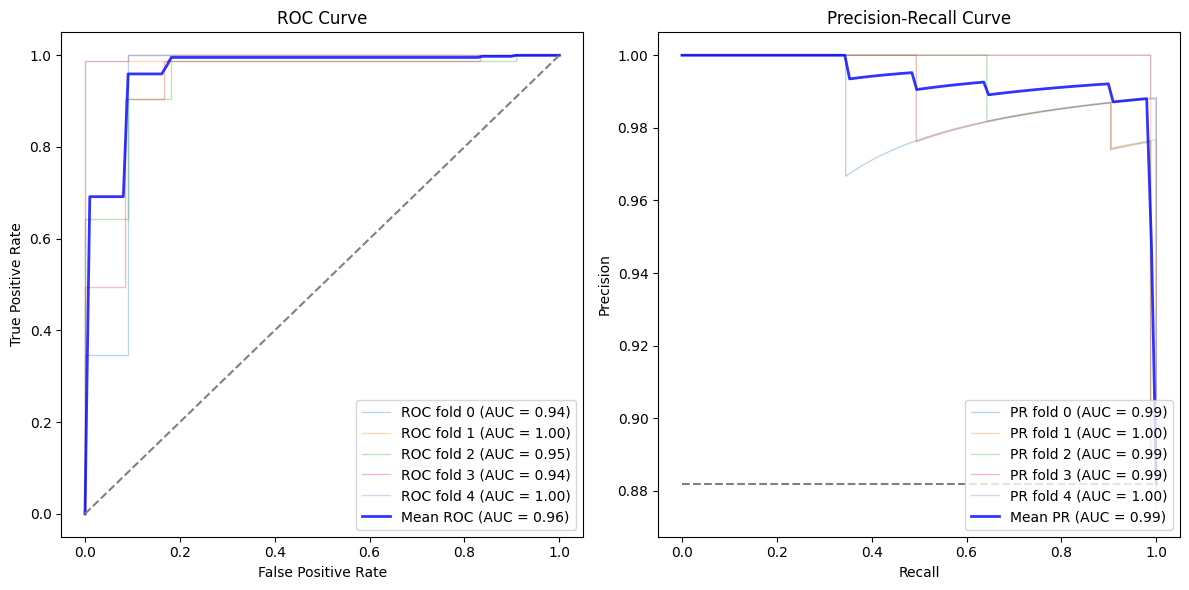

Average F1 score: 0.98
Average Accuracy: 0.97
Average AUROC: 0.97
Average AUPRC: 0.99


2025-02-24 13:24:36.334410: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-24 13:24:36.380892: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp_10.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import AUC
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras import layers


# Creating MLP model
def create_mlp_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='tanh', input_dim=input_dim))
    model.add(layers.Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(Dense(16, activation='tanh'))
    model.add(layers.Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[AUC(name='auc')])
    return model

input_dim = x_train_reduced.shape[1]

# Wrapping the Keras model with KerasClassifier
model = KerasClassifier(build_fn=lambda: create_mlp_model(input_dim), epochs=100, batch_size=32, verbose=0)

# Using the custom evaluation function
folds = 5
model_evaluation(model, x_train_reduced, y_train, folds)

# fit MLP model on training data
model.fit(x_train_reduced, y_train)


In [10]:
model.model.save('./results/models_new/mlp_thyroid_10_KernelPCA.h5')
del model

print('------------------------------ LOG MODEL ------------------------------')
functions.print_model_summary('./results/models_new/mlp_thyroid_10_KernelPCA.h5')

------------------------------ LOG MODEL ------------------------------
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_25 (Dense)            (None, 64)                704       
                                                                 
 dropout_20 (Dropout)        (None, 64)                0         
                                                                 
 dense_26 (Dense)            (None, 32)                2080      
                                                                 
 dropout_21 (Dropout)        (None, 32)                0         
                                                                 
 dense_27 (Dense)            (None, 32)                1056      
                                                                 
 dropout_22 (Dropout)        (None, 32)                0         
                                                

/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/4180989354.py:76: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasClassifier(build_fn=lambda: create_cnn_model(x_train_padded.shape[1]), epochs=100, batch_size=32, verbose=0)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:565: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model.fit(X_train[train], y_train[train])
2025-02-28 10:49:25.950603: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-28 10:49:26.004751: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:9

3/3 [==============================] - 0s 2ms/step


2025-02-28 10:49:35.057312: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:570: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, _ = roc_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:580: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precision, recall, _ = precision_recall_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:589: FutureW

3/3 [==============================] - 0s 2ms/step


2025-02-28 10:49:44.763022: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:570: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, _ = roc_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:580: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precision, recall, _ = precision_recall_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:589: FutureW

...

2025-02-28 10:49:54.128482: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:570: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, _ = roc_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:580: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precision, recall, _ = precision_recall_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:589: FutureW

3/3 [==============================] - 0s 2ms/step


2025-02-28 10:50:03.537913: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:570: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, _ = roc_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:580: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precision, recall, _ = precision_recall_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:589: FutureW

3/3 [==============================] - 0s 2ms/step


2025-02-28 10:50:12.387504: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:570: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fpr, tpr, _ = roc_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:580: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precision, recall, _ = precision_recall_curve(y_train[test], y_score)
/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_97738/1821789406.py:589: FutureW

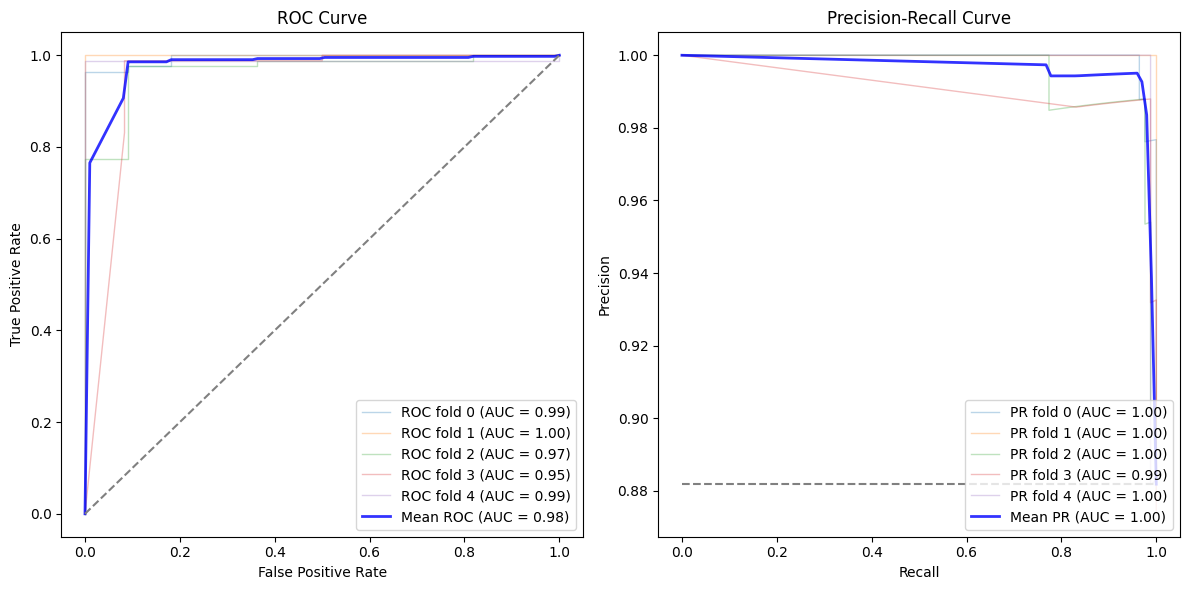

Average F1 score: 0.99
Average Accuracy: 0.98
Average AUROC: 0.98
Average AUPRC: 1.00


2025-02-28 10:50:12.985555: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-02-28 10:50:13.024606: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp_10.


In [9]:
import math
from tensorflow.keras.layers import Reshape
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, Flatten, MaxPooling2D, Reshape
from tensorflow.keras.optimizers import Adam


def create_cnn_model(input_dim):
    """
    Create a CNN model with adjusted pooling to handle small dimensions.

    Parameters:
    - input_dim: int, the number of input features.

    Returns:
    - model: Keras Sequential model.
    """
    # Calculate the dimensions after reshaping
    sqrt_p = math.ceil(math.sqrt(input_dim))
    
    model = Sequential()
    model.add(Reshape((sqrt_p, sqrt_p, 1), input_shape=(input_dim,)))
    
    # First convolutional layer
    model.add(Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same'))
    if sqrt_p > 2:  # Only apply pooling if dimensions allow
        model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
    model.add(Dropout(0.1))
    
    # Second convolutional layer
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
    if sqrt_p > 4:  # Only apply pooling if dimensions allow
        model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))
    model.add(Dropout(0.1))
    
    # Flatten and Dense layers
    model.add(Flatten())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['AUC'])
    return model

# Preprocessing to Pad the Data
def preprocess_data(X):
    """
    Pad the feature matrix to make it square.

    Parameters:
    - X: numpy array, input feature matrix.

    Returns:
    - X_padded: numpy array, padded feature matrix.
    """
    num_features = X.shape[1]
    sqrt_p = math.ceil(math.sqrt(num_features))
    padded_size = sqrt_p ** 2
    padding = padded_size - num_features

    # Pad features with zeros
    X_padded = np.pad(X, ((0, 0), (0, padding)), mode='constant', constant_values=0)
    return X_padded
    
# Flatten the y_train Series if it has a MultiIndex column structure
if isinstance(y_train.name, tuple):
    y_train_flat = y_train.rename("output")
else:
    y_train_flat = y_train

# Preprocess the training data to ensure square input
x_train_padded = preprocess_data(x_train_reduced)

# Wrapping the Keras model with KerasClassifier
model = KerasClassifier(build_fn=lambda: create_cnn_model(x_train_padded.shape[1]), epochs=100, batch_size=32, verbose=0)

# Evaluate the model using your custom function
folds = 5
model_evaluation(model, x_train_padded, y_train_flat, folds)

# Fit the model
model.fit(x_train_padded, y_train_flat)


In [10]:
model.model.save('./results/models_new/cnn_thyroid_10_KernelPCA.h5')
del model

print('------------------------------ LOG MODEL ------------------------------')
functions.print_model_summary('./results/models_new/cnn_thyroid_10_KernelPCA.h5')

------------------------------ LOG MODEL ------------------------------
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_5 (Reshape)         (None, 4, 4, 1)           0         
                                                                 
 conv2d_10 (Conv2D)          (None, 4, 4, 16)          160       
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 2, 2, 16)         0         
 2D)                                                             
                                                                 
 dropout_15 (Dropout)        (None, 2, 2, 16)          0         
                                                                 
 conv2d_11 (Conv2D)          (None, 2, 2, 32)          4640      
                                                                 
 dropout_16 (Dropout)        (None, 2, 2, 32)   

In [12]:
x_train_reduced

NameError: name 'x_train_reduced' is not defined

In [35]:
x_train_reduced.shape

(474, 10)

/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_48161/2220488289.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = torch.tensor(labels, dtype=torch.long)


Number of nodes: 474
Number of edges: 18087
Edge density: 0.0805


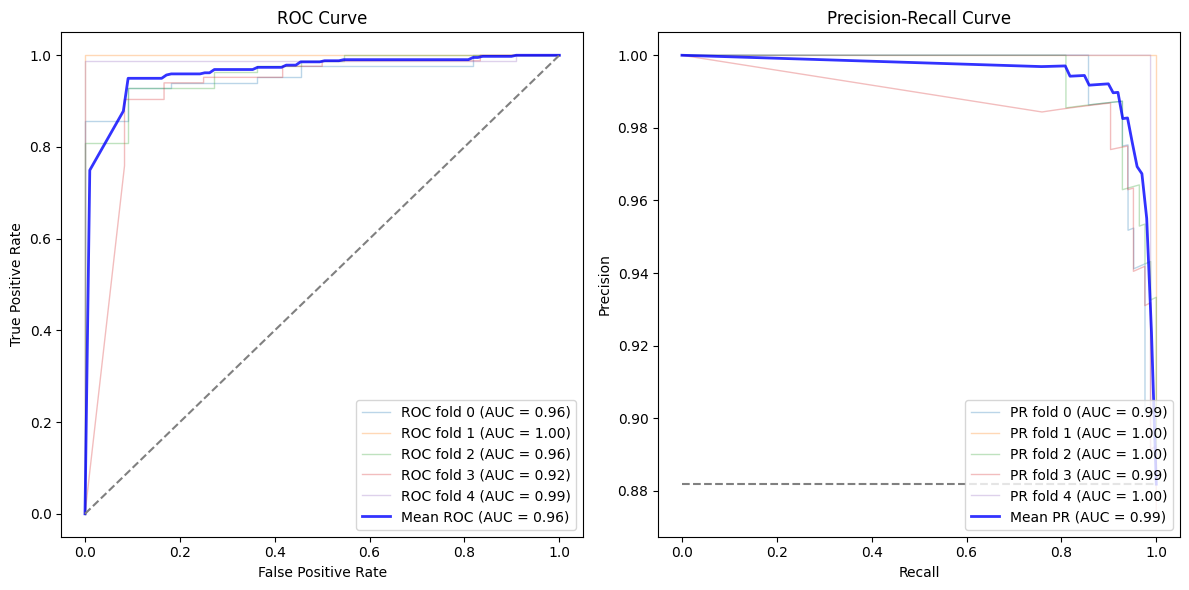

Average F1 score: 0.95
Average Accuracy: 0.92
Average AUROC: 0.97
Average AUPRC: 1.00
Entire model saved to ./results/models_new/gnn_thyroid_10_KernelPCA.pth
Model loaded successfully.


In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch.optim import Adam
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Create graph from feature matrix
def create_graph_from_features(features, threshold=0.5):
    similarity_matrix = cosine_similarity(features)
    G = nx.Graph()
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            if similarity_matrix[i, j] > threshold:
                G.add_edge(i, j, weight=similarity_matrix[i, j])
    return G

# Step 2: Convert to PyTorch Geometric Data object
def create_pyg_data(features, labels, graph):
    edge_index = torch.tensor(list(graph.edges)).t().contiguous()
    x = torch.tensor(features, dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

# Step 3: Define a GNN Model
class GCN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, 64)
        self.conv2 = GCNConv(64, 32)
        self.conv3 = GCNConv(32, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = torch.nn.functional.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        x = torch.relu(x)
        x = torch.nn.functional.dropout(x, p=0.5, training=self.training)
        x = self.conv3(x, edge_index)
        return torch.log_softmax(x, dim=1)

# Step 4: Evaluation Function
def gnn_model_evaluation(model, data, folds=5):
    cv = StratifiedKFold(n_splits=folds)
    y_train = data.y.cpu().numpy()

    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    precision_array = []
    recall_array = []
    pr_aucs = []
    mean_recall = np.linspace(0, 1, 100)

    f1_scores = []
    accuracy_scores = []

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    for i, (train_idx, test_idx) in enumerate(cv.split(data.x, y_train)):
        train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
        test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
        train_mask[train_idx] = True
        test_mask[test_idx] = True

        def reset_parameters(module):
            if hasattr(module, 'reset_parameters'):
                module.reset_parameters()

        model.apply(reset_parameters)

        optimizer = Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        model.train()

        # Compute class weights for imbalance handling
        class_counts = torch.bincount(data.y[train_mask])
        class_weights = 1.0 / class_counts.float()

        for epoch in range(100):
            optimizer.zero_grad()
            out = model(data)
            weighted_loss = torch.nn.functional.nll_loss(
                out[train_mask], data.y[train_mask], weight=class_weights
            )
            weighted_loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(data)
            y_score = torch.exp(out[test_mask])[:, 1].cpu().numpy()
            y_pred = out[test_mask].argmax(dim=1).cpu().numpy()

        # # Debugging Outputs
        # print(f"Fold {i + 1}")
        # print(f"Predictions: {y_pred}")
        # print(f"True labels: {data.y[test_mask].cpu().numpy()}")

        fpr, tpr, _ = roc_curve(data.y[test_mask].cpu().numpy(), y_score)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        ax1.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {i} (AUC = {roc_auc:.2f})')

        precision, recall, _ = precision_recall_curve(data.y[test_mask].cpu().numpy(), y_score)
        interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
        precision_array.append(interp_precision)
        pr_auc = auc(recall, precision)
        pr_aucs.append(pr_auc)

        ax2.plot(recall, precision, lw=1, alpha=0.3, label=f'PR fold {i} (AUC = {pr_auc:.2f})')

        f1_scores.append(f1_score(data.y[test_mask].cpu().numpy(), y_pred))
        accuracy_scores.append(accuracy_score(data.y[test_mask].cpu().numpy(), y_pred))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    ax1.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=.8)
    ax1.plot([0, 1], [0, 1], color='grey', linestyle='--')
    ax1.set_title('ROC Curve')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.legend(loc="lower right")

    mean_precision = np.mean(precision_array, axis=0)
    mean_pr_auc = auc(mean_recall, mean_precision)
    ax2.plot(mean_recall, mean_precision, color='b', label=f'Mean PR (AUC = {mean_pr_auc:.2f})', lw=2, alpha=.8)
    ax2.plot([0, 1], [np.mean(y_train), np.mean(y_train)], color='grey', linestyle='--')
    ax2.set_title('Precision-Recall Curve')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    print(f"Average F1 score: {np.mean(f1_scores):.2f}")
    print(f"Average Accuracy: {np.mean(accuracy_scores):.2f}")
    print(f"Average AUROC: {np.mean(aucs):.2f}")
    print(f"Average AUPRC: {np.mean(pr_aucs):.2f}")

# Step 5: Main Workflow
# Replace these with your actual data
# x_train_reduced = np.random.rand(418, 20)
# y_train = np.random.randint(0, 2, 418)

# Create graph and PyTorch Geometric Data
graph = create_graph_from_features(x_train_reduced)
data = create_pyg_data(x_train_reduced, y_train, graph)

# Debugging Graph Structure
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.edge_index.size(1)}")
print(f"Edge density: {data.edge_index.size(1) / (data.num_nodes ** 2):.4f}")

# Initialize and evaluate the model
model = GCN(num_features=x_train_reduced.shape[1], num_classes=2)
gnn_model_evaluation(model, data, folds=5)

# Save the trained model
model_save_path = './results/models_new/gnn_thyroid_10_KernelPCA.pth'
torch.save(model, model_save_path)
print(f"Entire model saved to {model_save_path}")

# Load the trained model
loaded_model = torch.load(model_save_path)
loaded_model.eval()
print("Model loaded successfully.")


/var/folders/hm/zfbz8bvd2c5_x7332044tj9c2lxsgx/T/ipykernel_48161/2060264190.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = torch.tensor(labels, dtype=torch.long)


Number of nodes: 474
Number of edges: 18087
Edge density: 0.0805
Fold 1
Predictions: [1 0 0 1 0 1 1 0 1 1 1 1 1 0 1 0 1 1 1 0 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 0
 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1]
True labels: [1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Fold 2
Predictions: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0]
True labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
Fold 3
Predictions: [1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 

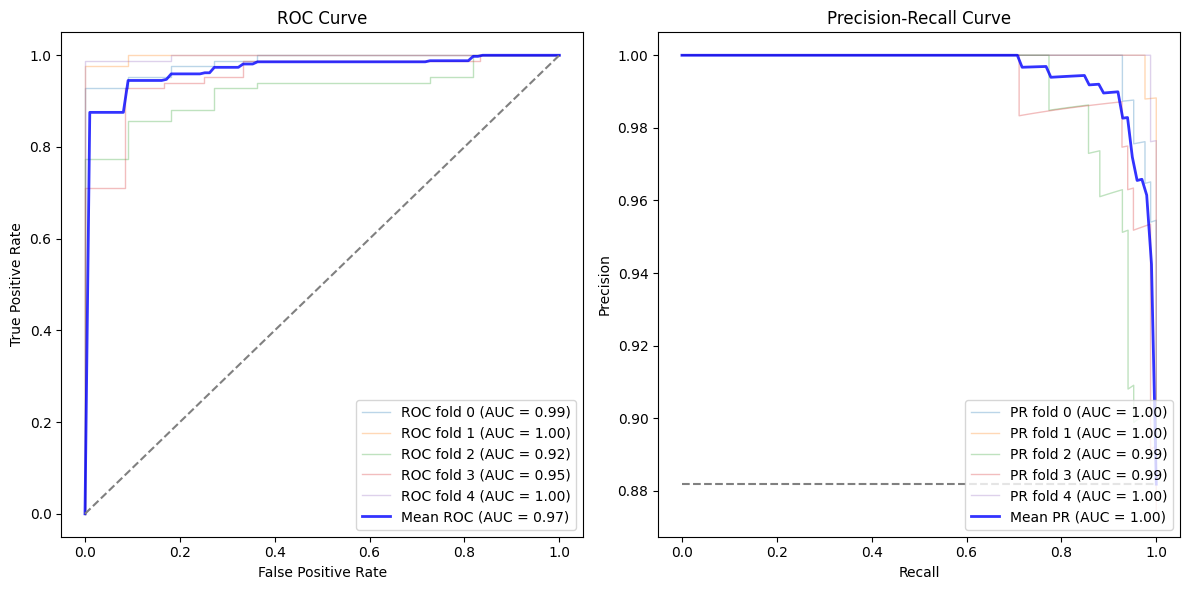

Average F1 score: 0.95
Average Accuracy: 0.92
Average AUROC: 0.97
Average AUPRC: 1.00
Entire model saved to ./results/models_new/transformer_thyroid_10_KernelPCA.pth
Model loaded successfully.


In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from torch_geometric.data import Data
from torch_geometric.nn import TransformerConv
from torch.optim import Adam
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Create graph from feature matrix
def create_graph_from_features(features, threshold=0.5):
    similarity_matrix = cosine_similarity(features)
    G = nx.Graph()
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            if similarity_matrix[i, j] > threshold:
                G.add_edge(i, j, weight=similarity_matrix[i, j])
    return G

# Step 2: Convert to PyTorch Geometric Data object
def create_pyg_data(features, labels, graph):
    edge_index = torch.tensor(list(graph.edges)).t().contiguous()
    x = torch.tensor(features, dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

# Step 3: Define a Transformer-based Graph Model
class GraphTransformer(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GraphTransformer, self).__init__()
        self.conv1 = TransformerConv(num_features, 64, heads=4, dropout=0.1)
        self.conv2 = TransformerConv(64 * 4, 32, heads=2, dropout=0.1)
        self.conv3 = TransformerConv(32 * 2, num_classes, heads=1, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = torch.nn.functional.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        x = torch.relu(x)
        x = torch.nn.functional.dropout(x, p=0.5, training=self.training)
        x = self.conv3(x, edge_index)
        return torch.log_softmax(x, dim=1)

# Step 4: Evaluation Function
def transformer_model_evaluation(model, data, folds=5):
    cv = StratifiedKFold(n_splits=folds)
    y_train = data.y.cpu().numpy()

    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    precision_array = []
    recall_array = []
    pr_aucs = []
    mean_recall = np.linspace(0, 1, 100)

    f1_scores = []
    accuracy_scores = []

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    for i, (train_idx, test_idx) in enumerate(cv.split(data.x, y_train)):
        train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
        test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
        train_mask[train_idx] = True
        test_mask[test_idx] = True

        def reset_parameters(module):
            if hasattr(module, 'reset_parameters'):
                module.reset_parameters()

        model.apply(reset_parameters)

        optimizer = Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        model.train()

        # Compute class weights for imbalance handling
        class_counts = torch.bincount(data.y[train_mask])
        class_weights = 1.0 / class_counts.float()

        for epoch in range(100):
            optimizer.zero_grad()
            out = model(data)
            weighted_loss = torch.nn.functional.nll_loss(
                out[train_mask], data.y[train_mask], weight=class_weights
            )
            weighted_loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(data)
            y_score = torch.exp(out[test_mask])[:, 1].cpu().numpy()
            y_pred = out[test_mask].argmax(dim=1).cpu().numpy()

        # Debugging Outputs
        print(f"Fold {i + 1}")
        print(f"Predictions: {y_pred}")
        print(f"True labels: {data.y[test_mask].cpu().numpy()}")

        fpr, tpr, _ = roc_curve(data.y[test_mask].cpu().numpy(), y_score)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        ax1.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {i} (AUC = {roc_auc:.2f})')

        precision, recall, _ = precision_recall_curve(data.y[test_mask].cpu().numpy(), y_score)
        interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
        precision_array.append(interp_precision)
        pr_auc = auc(recall, precision)
        pr_aucs.append(pr_auc)

        ax2.plot(recall, precision, lw=1, alpha=0.3, label=f'PR fold {i} (AUC = {pr_auc:.2f})')

        f1_scores.append(f1_score(data.y[test_mask].cpu().numpy(), y_pred))
        accuracy_scores.append(accuracy_score(data.y[test_mask].cpu().numpy(), y_pred))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    ax1.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=.8)
    ax1.plot([0, 1], [0, 1], color='grey', linestyle='--')
    ax1.set_title('ROC Curve')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.legend(loc="lower right")

    mean_precision = np.mean(precision_array, axis=0)
    mean_pr_auc = auc(mean_recall, mean_precision)
    ax2.plot(mean_recall, mean_precision, color='b', label=f'Mean PR (AUC = {mean_pr_auc:.2f})', lw=2, alpha=.8)
    ax2.plot([0, 1], [np.mean(y_train), np.mean(y_train)], color='grey', linestyle='--')
    ax2.set_title('Precision-Recall Curve')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    print(f"Average F1 score: {np.mean(f1_scores):.2f}")
    print(f"Average Accuracy: {np.mean(accuracy_scores):.2f}")
    print(f"Average AUROC: {np.mean(aucs):.2f}")
    print(f"Average AUPRC: {np.mean(pr_aucs):.2f}")

# Step 5: Main Workflow
# Create graph and PyTorch Geometric Data
graph = create_graph_from_features(x_train_reduced)
data = create_pyg_data(x_train_reduced, y_train, graph)

# Debugging Graph Structure
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.edge_index.size(1)}")
print(f"Edge density: {data.edge_index.size(1) / (data.num_nodes ** 2):.4f}")

# Initialize and evaluate the model
model = GraphTransformer(num_features=x_train_reduced.shape[1], num_classes=2)
transformer_model_evaluation(model, data, folds=5)

# Save the trained model
model_save_path = './results/models_new/transformer_thyroid_10_KernelPCA.pth'
torch.save(model, model_save_path)
print(f"Entire model saved to {model_save_path}")

# Load the trained model
loaded_model = torch.load(model_save_path)
loaded_model.eval()
print("Model loaded successfully.")


In [ ]:
functions.get_feature_importance(x_test, y_test, kernelpca_reducer, 
                                 './results/models_new/log_thyroid_10_KernelPCA.h5', 
                                 './results/feature_importance/log_thyroid_10_KernelPCA', 25)

4/4 [==============================] - 0s 2ms/step


2025-02-25 14:31:54.891011: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
  0%|                                      | 12/58189 [00:01<1:41:08,  9.59it/s]

1/4 [======>.......................] - ETA: 0s

  0%|                                     | 24/58189 [00:27<21:21:03,  1.32s/it]

4/4 [==============================] - 0s 4ms/step


...

1/4 [======>.......................] - ETA: 0s

  1%|▎                                   | 540/58189 [13:15<23:23:18,  1.46s/it]

1/4 [======>.......................] - ETA: 0s

  1%|▎                                   | 552/58189 [13:33<23:22:17,  1.46s/it]

4/4 [==============================] - 0s 4ms/step


In [ ]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, r2_score
from joblib import Parallel, delayed
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
import math

def preprocess_data(X):
    """
    Pads the feature matrix to make it square, required for CNN input.

    Parameters:
    - X: numpy array, input feature matrix.

    Returns:
    - X_padded: numpy array, padded feature matrix.
    """
    num_features = X.shape[1]
    sqrt_p = math.ceil(math.sqrt(num_features))
    padded_size = sqrt_p ** 2
    padding = padded_size - num_features

    # Pad features with zeros
    X_padded = np.pad(X, ((0, 0), (0, padding)), mode='constant', constant_values=0)
    
    return X_padded

def get_feature_importance(x_test, y_test, reducer, model_path, location, N, x_train):
    """
    Evaluates feature importance by permuting test dataset features and comparing model performance.

    Parameters:
    - x_test : DataFrame (Test data features)
    - y_test : Series (Test data target)
    - reducer : PCA or other dimensionality reduction object (Optional, used before prediction)
    - model_path : str (Path to saved model)
    - location : str (Directory to save output files)
    - N : int (Number of permutations for each feature)
    - x_train : DataFrame (Training data features, used to determine padding size)

    Outputs:
    - Plots and Pickle files of accuracy and R-squared differences.
    """

    # ✅ Load the model ONCE
    model = keras.models.load_model(model_path)

    # Convert DataFrame to NumPy array
    x_train_arr = x_train.values
    x_test_arr = x_test.values

    # ✅ Apply KernelPCA FIRST (force number of components to match training)
    if reducer is not None:
        x_train_transformed = reducer.fit_transform(x_train_arr)
        x_test_transformed = reducer.transform(x_test_arr)
    else:
        x_train_transformed = x_train_arr
        x_test_transformed = x_test_arr

    # ✅ Apply padding AFTER PCA transformation
    x_train_padded = preprocess_data(x_train_transformed)
    x_test_padded = preprocess_data(x_test_transformed)

    # ✅ Ensure shape consistency with the model
    if model.input_shape[1] != x_test_padded.shape[1]:
        raise ValueError(f"❌ Shape Mismatch: Model expects {model.input_shape[1]}, but got {x_test_padded.shape[1]}.")

    # ✅ Model Predictions on Original Test Data (Avoid Multiple Calls)
    y_pred_orig = np.round(model.predict(x_test_padded, verbose=0))
    y_pred_prob_orig = model.predict(x_test_padded, verbose=0)
    acc_orig = accuracy_score(y_test, y_pred_orig)
    r2_orig = r2_score(y_test, y_pred_prob_orig)

    # ✅ Initialize arrays to store accuracy and R-squared differences
    num_features = x_test.shape[1]
    acc_diffs = np.zeros(num_features)
    r2_diffs = np.zeros(num_features)

    def calculate_diffs(col, model):
        """
        Computes accuracy and R² differences for a single feature column.
        """
        x_test_permuted = x_test_arr.copy()

        # ✅ Vectorized Shuffle (Faster than Loop)
        for _ in range(N):
            np.random.shuffle(x_test_permuted[:, col])  # In-place shuffle (Faster)
            
            # ✅ Apply PCA transformation
            x_test_permuted_transformed = reducer.transform(x_test_permuted) if reducer else x_test_permuted

            # ✅ Apply padding AFTER PCA transformation
            x_test_permuted_padded = preprocess_data(x_test_permuted_transformed)

            # ✅ Single model inference (No redundant loading)
            y_pred_permuted = np.round(model.predict(x_test_permuted_padded, verbose=0))
            y_pred_prob_permuted = model.predict(x_test_permuted_padded, verbose=0)

            acc_permuted = accuracy_score(y_test, y_pred_permuted)
            r2_permuted = r2_score(y_test, y_pred_prob_permuted)

        return (acc_orig - acc_permuted) / N, (r2_orig - r2_permuted) / N  # ✅ Averaging inside function

    # ✅ Parallel Processing for Speed (Avoid Redundant Model Loads)
    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(calculate_diffs)(col, model) for col in tqdm(range(num_features), desc="🔄 Calculating Feature Importance" , 
                                                             dynamic_ncols=True,  # ✅ Keeps progress bar on one line
                                                             leave=True,          # ✅ Keeps only final progress bar visible
                                                             position=0)
    )

    # ✅ Store accuracy and R-squared differences
    acc_diffs, r2_diffs = zip(*results)
    acc_diffs, r2_diffs = np.array(acc_diffs), np.array(r2_diffs)

    os.makedirs(location, exist_ok=True)

    # ✅ Save Accuracy Difference Plot
    plt.figure(figsize=(8, 6))
    plt.plot(range(num_features), acc_diffs, marker='o', linestyle='-')
    plt.xlabel('Feature Index')
    plt.ylabel('Accuracy Difference')
    plt.title('Accuracy Difference by Feature Permutation')
    plt.savefig(os.path.join(location, "accuracy_diff.png"))
    plt.close()

    # ✅ Save R-Squared Difference Plot
    plt.figure(figsize=(8, 6))
    plt.plot(range(num_features), r2_diffs, marker='s', linestyle='-', color='r')
    plt.xlabel('Feature Index')
    plt.ylabel('R-Squared Difference')
    plt.title('R-Squared Difference by Feature Permutation')
    plt.savefig(os.path.join(location, "r2_diff.png"))
    plt.close()

    # ✅ Save Pickle Files
    with open(os.path.join(location, "accuracy_diff.pkl"), 'wb') as fp:
        pickle.dump(acc_diffs, fp)
    with open(os.path.join(location, "r2_diff.pkl"), 'wb') as fp:
        pickle.dump(r2_diffs, fp)

    print(f"✅ Feature Importance Analysis Completed! Results saved in {location}")


# get_feature_importance(
#     x_test, 
#     y_test, 
#     kernelpca_reducer, 
#     './results/models_new/cnn_thyroid_10_KernelPCA.h5', 
#     './results/feature_importance/cnn_thyroid_10_KernelPCA', 
#     10, 
#     x_train
# )


In [ ]:
functions.get_feature_importance(x_test, y_test, kernelpca_reducer, 
                                 './results/models_new/mlp_thyroid_10_KernelPCA.h5', 
                                 './results/feature_importance/mlp_thyroid_10_KernelPCA', 25)

In [ ]:
import torch
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, r2_score
from joblib import Parallel, delayed
from tqdm import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch.optim import Adam
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity


def get_feature_importance(x_test, y_test, reducer, model_path, location, N, x_train):
    """
    Evaluates feature importance using a GNN model trained with PyTorch.

    Parameters:
    - x_test : DataFrame (Test data features)
    - y_test : Series (Test data target)
    - reducer : PCA or other dimensionality reduction object (Optional, used before prediction)
    - model_path : str (Path to saved PyTorch model)
    - location : str (Directory to save output files)
    - N : int (Number of permutations for each feature)
    - x_train : DataFrame (Training data features, used to determine padding size)

    Outputs:
    - PNG plots of accuracy and R-squared differences.
    - Pickle files of accuracy and R-squared differences.
    """

    # Load the saved PyTorch model
    model = torch.load(model_path)
    model.eval()

    # Convert DataFrame to NumPy array
    x_train_arr = x_train.values
    x_test_arr = x_test.values

    # Apply KernelPCA FIRST (force number of components to match training)
    num_pca_components = 10  # Must match training
    if reducer is not None:
        reducer.n_components = num_pca_components  # Ensure consistent PCA components
        x_train_transformed = reducer.fit_transform(x_train_arr)
        x_test_transformed = reducer.transform(x_test_arr)
    else:
        x_train_transformed = x_train_arr
        x_test_transformed = x_test_arr

    # Debugging: Verify feature consistency
    print(f"✅ x_train_transformed shape: {x_train_transformed.shape}")
    print(f"✅ x_test_transformed shape: {x_test_transformed.shape}")

    # Precompute graph structure for original test data
    graph_test = create_graph_from_features(x_test_transformed)
    data_test = create_pyg_data(x_test_transformed, y_test.values, graph_test)

    # Debugging: Print dataset shapes
    print(f"✅ Number of nodes in graph: {data_test.num_nodes}")
    print(f"✅ Number of edges: {data_test.edge_index.size(1)}")

    # Ensure model expects the correct input feature size
    assert data_test.x.shape[1] == num_pca_components, f"❌ Feature Mismatch! Model expects {num_pca_components}, but got {data_test.x.shape[1]}."

    # Model Predictions on Original Test Data
    with torch.no_grad():
        out = model(data_test)
        y_pred_orig = out.argmax(dim=1).cpu().numpy()
        y_pred_prob_orig = torch.exp(out)[:, 1].cpu().numpy()

    acc_orig = accuracy_score(y_test, y_pred_orig)
    r2_orig = r2_score(y_test, y_pred_prob_orig)

    # Initialize arrays to store accuracy and R-squared differences
    num_features = x_test.shape[1]  
    acc_diffs = np.zeros(num_features)
    r2_diffs = np.zeros(num_features)

    # Precompute reusable transformed features for permutations
    def precompute_permuted_data(col):
        """
        Precomputes permuted datasets for a single feature column.
        """
        permuted_data_list = []
        for _ in range(N):
            x_test_permuted = x_test_arr.copy()
            x_test_permuted[:, col] = shuffle(x_test_permuted[:, col])

            # Apply PCA transformation if applicable
            if reducer is not None:
                x_test_permuted_transformed = reducer.transform(x_test_permuted)
            else:
                x_test_permuted_transformed = x_test_permuted

            permuted_data_list.append(x_test_permuted_transformed)

        return permuted_data_list

    def calculate_diffs(col):
        """
        Calculates accuracy and R-squared differences for a single feature column.
        """
        acc_diff_sum = 0.0
        r2_diff_sum = 0.0

        # Precompute permuted datasets for this column
        permuted_data_list = precompute_permuted_data(col)

        for permuted_data in permuted_data_list:
            # Convert to PyTorch Geometric format
            graph_permuted = create_graph_from_features(permuted_data)
            data_permuted = create_pyg_data(permuted_data, y_test.values, graph_permuted)

            # Model Predictions on Permuted Data
            with torch.no_grad():
                out_permuted = model(data_permuted)
                y_pred_permuted = out_permuted.argmax(dim=1).cpu().numpy()
                y_pred_prob_permuted = torch.exp(out_permuted)[:, 1].cpu().numpy()

            acc_permuted = accuracy_score(y_test, y_pred_permuted)
            r2_permuted = r2_score(y_test, y_pred_prob_permuted)

            acc_diff_sum += acc_orig - acc_permuted
            r2_diff_sum += r2_orig - r2_permuted

        return acc_diff_sum / N, r2_diff_sum / N

    # Compute feature importance in parallel (LIMIT TO FIRST 50 FEATURES)
    results = Parallel(n_jobs=-1)(
        delayed(calculate_diffs)(col) for col in tqdm(range(num_features), desc="🔄 Calculating Feature Importance")
    )

    # Store accuracy and R-squared differences
    for col, (acc_diff, r2_diff) in enumerate(results):
        acc_diffs[col] = acc_diff
        r2_diffs[col] = r2_diff

    os.makedirs(location, exist_ok=True)

    # Save results as pickle files
    with open(os.path.join(location, "accuracy_diff.pkl"), 'wb') as fp:
        pickle.dump(acc_diffs, fp)
    with open(os.path.join(location, "r2_diff.pkl"), 'wb') as fp:
        pickle.dump(r2_diffs, fp)

    # ✅ Save Accuracy Difference Plot
    plt.figure(figsize=(8, 6))
    plt.plot(range(num_features), acc_diffs, marker='s', linestyle='-', color='r')
    plt.xlabel('Feature Index')
    plt.ylabel('Accuracy Difference')
    plt.title('Accuracy Difference by Feature Permutation')
    plt.savefig(os.path.join(location, "accuracy_diff.png"))

    # ✅ Save R-Squared Difference Plot
    plt.figure(figsize=(8, 6))
    plt.plot(range(num_features), r2_diffs, marker='s', linestyle='-', color='r')
    plt.xlabel('Feature Index')
    plt.ylabel('R-Squared Difference')
    plt.title('R-Squared Difference by Feature Permutation')
    plt.savefig(os.path.join(location, "r2_diff.png"))
    plt.close()



In [ ]:
# get_feature_importance(
#     x_test, 
#     y_test, 
#     kernelpca_reducer, 
#     './results/models_new/gnn_thyroid_10_KernelPCA.pth',
#     './results/feature_importance/gnn_thyroid_10_KernelPCA', 
#     10, 
#     x_train
# )


In [ ]:
# get_feature_importance(
#     x_test, 
#     y_test, 
#     kernelpca_reducer, 
#     './results/models_new/transformer_thyroid_10_KernelPCA.pth',
#     './results/feature_importance/transformer_thyroid_10_KernelPCA', 
#     10, 
#     x_train
# )